# 06 — Case study: one market, three models, one exotic trade

Notebooks 01–05 validate each engine in isolation. This one asks the question a trading
desk actually cares about: **how much does the model change the price and the hedge of a
real exotic trade, once every model reproduces the same vanilla market?**

The trade is the classic embedded exotic of the structured-products world: a 1-year
**down-and-in put**, strike 100%, barrier 70%, monitored daily — the short put inside an
autocallable note. Issuance desks are structurally short this payoff in size; how it is
priced and hedged is not an academic question.

The experiment design follows Schoutens, Simons & Tistaert (2004), *A Perfect Calibration!
Now What?*: models fitted to the **same vanilla surface** can still disagree violently on
path-dependent payoffs, because vanillas pin only the marginal law of $S_T$ at each
expiry — a barrier reads the **joint law of the whole path**, which calibration never sees.

| model | origin | what it knows about the market |
|---|---|---|
| Black-Scholes (Phase 1) | flat vol = the 1Y ATM implied vol | the ATM point only |
| Heston (Phase 4) | calibrated to 1,718 real SPX options, RMSE 1.3 vol pts (notebook 04) | the smile, with mean-reverting vol dynamics |
| rough Bergomi (Phase 5) | $H = 0.1$, $\eta = 1.9$, $\rho = -0.9$ from the rough-vol literature; $\xi_0$ solved to hit the same ATM anchor | the smile, with rough vol dynamics |

As in notebooks 01–05: fully offline, seeded, and every claim asserted in-cell.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "exotic_option_pricer").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr

np.set_printoptions(precision=6, suppress=True)

from exotic_option_pricer.engines import MonteCarloEngine
from exotic_option_pricer.instruments import BarrierOption
from exotic_option_pricer.models import BlackScholesModel, HestonModel, RoughBergomiModel

S0, K, H_BAR, T, R = 100.0, 100.0, 70.0, 1.0, 0.03
N_PATHS, N_STEPS = 100_000, 252            # daily barrier monitoring
DT = T / N_STEPS
DISC = float(np.exp(-R * T))

# Phase 4 output: Heston calibrated to 1,718 SPX options across 8 expiries (notebook 04).
# Feller is violated (2 kappa theta < xi^2) — live calibrations do this routinely; the
# QE simulation below handles the mass at v = 0 natively.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    heston = HestonModel(v0=0.033, kappa=13.0, theta=0.048, xi=3.0, rho=-0.64)

# The single anchor every model must reproduce: the 1Y ATM put
p_atm = float(heston.price(S0, K, T, R, 'put'))
sigma_atm = BlackScholesModel.implied_vol(p_atm, S0, K, T, R, 'put')
bs = BlackScholesModel(sigma=sigma_atm)
assert abs(float(bs.price(S0, K, T, R, 'put')) - p_atm) < 1e-9   # Phase 1 IV round-trip
print(f"1Y ATM put (the anchor): {p_atm:.4f}   ->   ATM implied vol {100 * sigma_atm:.3f}%")

1Y ATM put (the anchor): 6.2430   ->   ATM implied vol 19.444%


## One market, three calibrations

Black-Scholes gets the trader's flat-vol shortcut: $\sigma$ = the 1Y ATM implied vol —
exactly what a screen would show. Heston keeps its Phase 4 SPX calibration untouched. For
rough Bergomi, roughness and leverage come from the literature ($H = 0.1$:
Gatheral-Jaisson-Rosenbaum 2018; $\eta = 1.9$, $\rho = -0.9$: Bayer-Friz-Gatheral 2016)
and the forward-variance level $\xi_0$ is solved to reprice the **same 1Y ATM put**. Since
$v_t \propto \xi_0$ exactly in this model, the ATM vol is monotone in $\xi_0$ and the
fixed point $\xi_0 \leftarrow \xi_0\,(\sigma_{\mathrm{target}}/\sigma_{\mathrm{model}})^2$
converges below a basis point in three steps.

This is deliberately *not* a joint recalibration of all four rBergomi parameters: the
experiment needs a common anchor, not a smile-fitting contest — and the Schoutens result
is precisely that closing the vanilla gap does not close the exotic gap. The smiles below
show how the three models read the same market.

In [2]:
xi0 = sigma_atm ** 2
for _ in range(4):
    rb = RoughBergomiModel(xi0=xi0, eta=1.9, H=0.1, rho=-0.9)
    iv_atm_rb = float(rb.iv_surface(S0, np.array([K]), np.array([T]), R)[0, 0])
    print(f"xi0 = {xi0:.5f}   ->   rBergomi ATM iv {100 * iv_atm_rb:.3f}%"
          f"   (target {100 * sigma_atm:.3f}%)")
    if abs(iv_atm_rb - sigma_atm) < 1e-4:
        break
    xi0 *= (sigma_atm / iv_atm_rb) ** 2
assert abs(iv_atm_rb - sigma_atm) < 5e-4        # anchored to < 5 bps of vol

p_rb_van, se_rb_van = rb.price_european_conditional(S0, K, T, R, 'put')
print(f"\nvanilla anchor:  BS = Heston {p_atm:.4f}   |   rBergomi {p_rb_van:.4f}"
      f" (SE {se_rb_van:.4f})")
assert abs(p_rb_van - p_atm) < 0.05             # all three models agree on the anchor

xi0 = 0.03781   ->   rBergomi ATM iv 16.811%   (target 19.444%)


xi0 = 0.05058   ->   rBergomi ATM iv 19.204%   (target 19.444%)


xi0 = 0.05185   ->   rBergomi ATM iv 19.424%   (target 19.444%)


xi0 = 0.05196   ->   rBergomi ATM iv 19.442%   (target 19.444%)



vanilla anchor:  BS = Heston 6.2430   |   rBergomi 6.2424 (SE 0.0119)


implied vol at the barrier strike (K = 70):  BS 19.4%   Heston 28.2%   rBergomi 29.7%


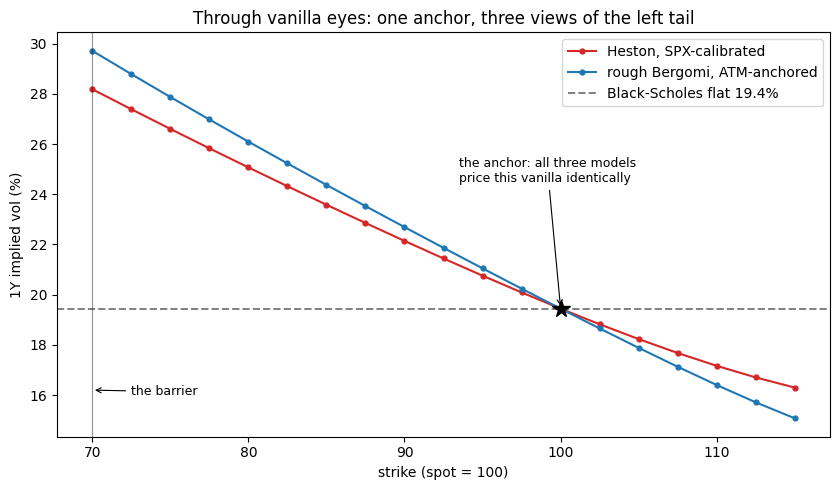

In [3]:
strikes = np.arange(70.0, 116.0, 2.5)
ivs_heston = np.array([
    BlackScholesModel.implied_vol(float(heston.price(S0, k, T, R, 'put')),
                                  S0, k, T, R, 'put')
    for k in strikes
])
ivs_rb = rb.iv_surface(S0, strikes, np.array([T]), R)[0]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(strikes, 100 * ivs_heston, 'o-', color='C3', ms=3.5, lw=1.5,
        label='Heston, SPX-calibrated')
ax.plot(strikes, 100 * ivs_rb, 'o-', color='C0', ms=3.5, lw=1.5,
        label='rough Bergomi, ATM-anchored')
ax.axhline(100 * sigma_atm, color='gray', ls='--', lw=1.4,
           label=f'Black-Scholes flat {100 * sigma_atm:.1f}%')
ax.plot([K], [100 * sigma_atm], 'k*', ms=13, zorder=5)
ax.annotate('the anchor: all three models\nprice this vanilla identically',
            xy=(K, 100 * sigma_atm), xytext=(93.5, 24.5), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.axvline(H_BAR, color='k', lw=0.9, alpha=0.4)
ax.annotate('the barrier', xy=(H_BAR, 16.2), xytext=(72.5, 16.0), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set(xlabel='strike (spot = 100)', ylabel='1Y implied vol (%)',
       title='Through vanilla eyes: one anchor, three views of the left tail')
ax.legend(loc='upper right')
fig.tight_layout()

print(f"implied vol at the barrier strike (K = 70):  BS {100 * sigma_atm:.1f}%   "
      f"Heston {100 * ivs_heston[0]:.1f}%   rBergomi {100 * ivs_rb[0]:.1f}%")

## The trade, priced three ways

Down-and-in put, $K = 100$, $H = 70$, $T = 1$, **daily monitoring** (252 observations —
the contractual reality of these products, and exactly what the simulated paths monitor).

- **Black-Scholes** prices in closed form: Reiner-Rubinstein (1991) evaluated at the
  Broadie-Glasserman-Kou shifted barrier $H\,e^{-\beta\sigma\sqrt{\Delta t}}$
  ($\beta \approx 0.5826$), which maps the continuous-monitoring formula to the
  daily-monitored contract (notebook 03 measures this correction). Cross-checked below
  against GBM Monte Carlo.
- **Heston** has no barrier closed form: Andersen QE paths (Phase 4), priced through the
  Phase 3 `payoff(paths)` contract.
- **rough Bergomi**: hybrid-scheme paths (Phase 5) — *same instrument object, same
  engine, zero new code*.

Cross-checks in this cell: exact in-out parity $V_{in} + V_{out} = V_{vanilla}$ path by
path on all three path sets; each model's simulated ATM vanilla against its own
semi-closed form (Heston, Gil-Pelaez) or conditional estimator (rBergomi); and the GBM
barrier-hit frequency against the closed-form first-passage probability at the shifted
barrier.

In [4]:
dip = BarrierOption(K=K, barrier=H_BAR, barrier_type='down-and-in', option_type='put')
dop = BarrierOption(K=K, barrier=H_BAR, barrier_type='down-and-out', option_type='put')

def vanilla_put(paths):
    return np.maximum(K - paths[:, -1], 0.0)

engine = MonteCarloEngine(n_paths=N_PATHS, n_steps=N_STEPS, seed=42)

# Black-Scholes: closed form at the BGK barrier + GBM Monte Carlo cross-check
H_eff = BarrierOption.continuity_correction(H_BAR, sigma_atm, DT, 'down')
bs_dip = BarrierOption.analytical_price(S0, K, T, R, sigma_atm, H_eff,
                                        'down-and-in', 'put')
gbm_paths = engine.simulate_gbm(S0, T, R, sigma_atm)
res_bs = engine.price(dip.payoff, gbm_paths, R, T)
z_bs = (res_bs.price - bs_dip) / res_bs.std_error
print(f"BS: closed form (BGK) {bs_dip:.4f}   GBM MC {res_bs.price:.4f}"
      f" (SE {res_bs.std_error:.4f})   z = {z_bs:+.2f}")
assert abs(z_bs) < 3

# Heston: QE paths | rough Bergomi: hybrid paths — same instrument, same engine
h_paths = engine.simulate_heston(S0, 0.033, T, R, kappa=13.0, theta=0.048, xi=3.0,
                                 rho=-0.64, n_steps=N_STEPS)
rb_paths = rb.simulate(S0, T, R, n_paths=N_PATHS, n_steps=N_STEPS, seed=42)
res_h = engine.price(dip.payoff, h_paths, R, T)
res_rb = engine.price(dip.payoff, rb_paths, R, T)

# consistency: each model's simulated ATM vanilla vs its own pricer
res_h_van = engine.price(vanilla_put, h_paths, R, T)
res_rb_van = engine.price(vanilla_put, rb_paths, R, T)
z_h_van = (res_h_van.price - p_atm) / res_h_van.std_error
z_rb_van = (res_rb_van.price - p_rb_van) / float(np.hypot(res_rb_van.std_error, se_rb_van))
print(f"simulated ATM vanilla vs model price:  Heston z = {z_h_van:+.2f}   "
      f"rBergomi z = {z_rb_van:+.2f}")
assert abs(z_h_van) < 3 and abs(z_rb_van) < 3

# exact in-out parity, path by path, on every model's paths
for paths_ in (gbm_paths, h_paths, rb_paths):
    gap = np.max(np.abs(dip.payoff(paths_) + dop.payoff(paths_) - vanilla_put(paths_)))
    assert gap < 1e-10
print("in-out parity V_in + V_out = V_vanilla: exact on all three path sets")

# risk-neutral probability of touching the barrier within the year (daily monitoring)
p_hit = {name: float(np.mean(np.min(p_, axis=1) <= H_BAR))
         for name, p_ in (('BS', gbm_paths), ('Heston', h_paths), ('rBergomi', rb_paths))}
nu = R - 0.5 * sigma_atm ** 2
b_ = np.log(H_eff / S0)
p_hit_cf = float(ndtr((b_ - nu * T) / (sigma_atm * np.sqrt(T)))
                 + (H_eff / S0) ** (2 * nu / sigma_atm ** 2)
                 * ndtr((b_ + nu * T) / (sigma_atm * np.sqrt(T))))
z_hit = (p_hit['BS'] - p_hit_cf) / np.sqrt(p_hit_cf * (1 - p_hit_cf) / N_PATHS)
print(f"GBM first-passage: closed form {100 * p_hit_cf:.2f}%   "
      f"simulated {100 * p_hit['BS']:.2f}%   z = {z_hit:+.2f}")
assert abs(z_hit) < 3

print(f"\n{'model':>10} {'DIP price':>10} {'SE':>8} {'vs BS':>7} {'P(touch)':>9}")
print(f"{'BS':>10} {bs_dip:>10.4f} {'--':>8} {'--':>7} {100 * p_hit_cf:>8.1f}%")
for name, res_ in (('Heston', res_h), ('rBergomi', res_rb)):
    print(f"{name:>10} {res_.price:>10.4f} {res_.std_error:>8.4f}"
          f" {res_.price / bs_dip:>6.2f}x {100 * p_hit[name]:>8.1f}%")

# the headline: both smile-aware models price the trade at > 2x the flat-vol number
assert res_h.price > 2.0 * bs_dip
assert res_rb.price > 2.0 * bs_dip

BS: closed form (BGK) 1.5994   GBM MC 1.5978 (SE 0.0216)   z = -0.07


simulated ATM vanilla vs model price:  Heston z = +0.03   rBergomi z = +0.43
in-out parity V_in + V_out = V_vanilla: exact on all three path sets
GBM first-passage: closed form 5.51%   simulated 5.51%   z = +0.06

     model  DIP price       SE   vs BS  P(touch)
        BS     1.5994       --      --      5.5%
    Heston     4.1322   0.0377   2.58x     13.6%
  rBergomi     4.5045   0.0406   2.82x     14.7%


## One chart: vanilla agreement, exotic divergence

As $H \to S_0$ the down-and-in put degenerates into the plain vanilla put and the three
curves must meet at the anchor — measured below, they agree there to ~0.3%. Moving left
the barrier deepens, the contract reads more of the path, and the curves fan out: at the
contractual $H = 70$ the smile-aware models price the trade at **2.6–2.8x** the flat-vol
number, while still disagreeing with *each other* by ~9%.

Two layers of model risk in one picture:

1. **Smile risk** (BS vs the rest): a factor of ~2.6. The flat-vol model believes the
   barrier is touched with probability 5.5%; the calibrated models say ~14%.
2. **Dynamics risk** (Heston vs rough Bergomi): ~9% between two models that both fit
   SPX-shaped smiles — the part of the price the vanilla market cannot identify at all,
   and the reason exotic desks carry model reserves.

model spread at H = 97.5 (vanilla limit): 0.30%
model spread at H = 70.0 (the trade):     181.6%


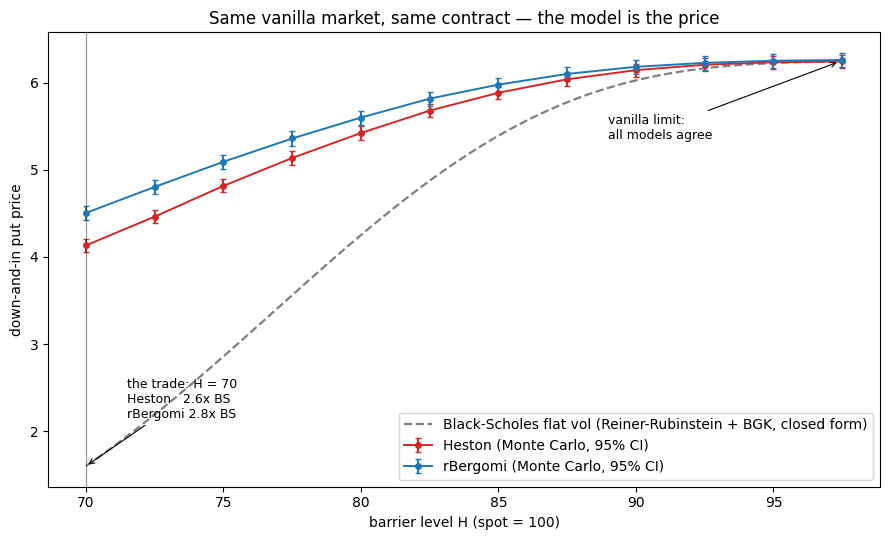

In [5]:
H_grid = np.arange(70.0, 97.6, 2.5)
curves, errs = {}, {}
for name, paths_ in (('Heston', h_paths), ('rBergomi', rb_paths)):
    vals, ses = [], []
    for h_ in H_grid:
        po = DISC * BarrierOption(K=K, barrier=h_, barrier_type='down-and-in',
                                  option_type='put').payoff(paths_)
        vals.append(float(np.mean(po)))
        ses.append(float(np.std(po, ddof=1) / np.sqrt(N_PATHS)))
    curves[name], errs[name] = np.array(vals), np.array(ses)

H_fine = np.arange(70.0, 97.51, 0.25)
bs_curve = np.array([
    BarrierOption.analytical_price(
        S0, K, T, R, sigma_atm,
        BarrierOption.continuity_correction(h_, sigma_atm, DT, 'down'),
        'down-and-in', 'put')
    for h_ in H_fine
])

for c in (curves['Heston'], curves['rBergomi'], bs_curve):
    assert np.all(np.diff(c) > 0)              # deeper barrier -> cheaper, always

ends = (curves['Heston'][-1], curves['rBergomi'][-1], bs_curve[-1])
spread_vanilla = (max(ends) - min(ends)) / bs_curve[-1]
spread_deep = (max(curves['Heston'][0], curves['rBergomi'][0]) - bs_curve[0]) / bs_curve[0]
print(f"model spread at H = 97.5 (vanilla limit): {100 * spread_vanilla:.2f}%")
print(f"model spread at H = 70.0 (the trade):     {100 * spread_deep:.1f}%")
assert spread_vanilla < 0.01
assert spread_deep > 1.0

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(H_fine, bs_curve, '--', color='gray', lw=1.6,
        label='Black-Scholes flat vol (Reiner-Rubinstein + BGK, closed form)')
for name, color in (('Heston', 'C3'), ('rBergomi', 'C0')):
    ax.errorbar(H_grid, curves[name], yerr=1.96 * errs[name], fmt='o-', color=color,
                ms=4, lw=1.4, capsize=2, label=f'{name} (Monte Carlo, 95% CI)')
ax.axvline(H_BAR, color='k', lw=0.9, alpha=0.4)
ax.annotate(f'the trade: H = 70\nHeston   {res_h.price / bs_dip:.1f}x BS\n'
            f'rBergomi {res_rb.price / bs_dip:.1f}x BS',
            xy=(H_BAR, bs_curve[0]), xytext=(71.5, 2.15), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.annotate('vanilla limit:\nall models agree', xy=(97.4, bs_curve[-1]),
            xytext=(89.0, 5.35), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set(xlabel='barrier level H (spot = 100)', ylabel='down-and-in put price',
       title='Same vanilla market, same contract — the model is the price')
ax.legend(loc='lower right')
fig.tight_layout()

img_dir = ROOT / 'docs' / 'img'
img_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(img_dir / 'model_risk_fan_out.png', dpi=150, bbox_inches='tight')

## The hedge changes too

Price is what you book; delta is what you do every day. Numerical deltas for all three
models come from **path rescaling under common random numbers** (the Phase 3 machinery,
notebook 03): every simulation here writes $S_t = S_0\,e^{X_t}$ with $X_t$ independent of
$S_0$ — exact log-space GBM, the QE log-spot recursion, the rBergomi log-Euler forward —
so multiplying a stored path set by $1 \pm h$ *is* the simulation from the bumped spot
with identical randomness, and the barrier indicator is re-evaluated on the shifted paths.

Two checks pin the method before trusting it:

1. under Black-Scholes, the rescaling delta must match the finite difference of the
   Reiner-Rubinstein closed form at every barrier level;
2. under Heston, the *vanilla* rescaling delta must match the exact delta from the
   differentiated characteristic function (Phase 4 — no bumping anywhere).

What to expect (measured below): as $H \to S_0$, each model's DIP delta converges to its
own vanilla-put delta — and these already disagree: **BS $-0.40$, Heston $-0.30$, rough
Bergomi $-0.28$**. Same anchor price, ~30% different hedge, before any exotic enters the
book. The origin is the classic smile-delta effect: with $\rho < 0$ a down-move arrives
together with a vol rise, and models that know this split the sensitivity between the
spot and vol channels differently; which delta actually hedges best depends on the true
dynamics — itself model risk, invisible to the vanilla market. In the mid-barrier region
the gap peaks: at $H = 85$, hedging with the BS delta means shorting ~55% more spot than
the rough Bergomi delta.

Heston vanilla delta: exact CF -0.3026   rescaling -0.3012 (SE 0.0012)   z = +1.13


BS delta: rescaling vs closed-form FD, max |z| over 12 barrier levels = 1.62
vanilla-put delta:  BS -0.401   Heston -0.303   rBergomi -0.278

DIP delta at H = 70:  BS -0.183   Heston -0.183   rBergomi -0.180
DIP delta at H = 85:  BS -0.411   Heston -0.284   rBergomi -0.266
hedge ratio BS / rBergomi at H = 85: 1.55x


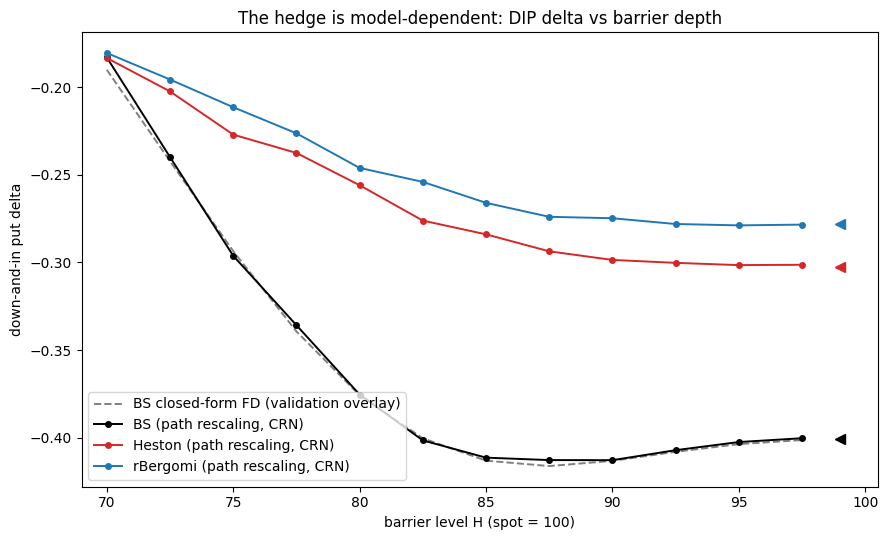

In [6]:
H_REL = 0.01

def rescaling_delta(payoff_fn, paths_):
    d_i = DISC * (payoff_fn(paths_ * (1 + H_REL)) - payoff_fn(paths_ * (1 - H_REL)))
    d_i /= 2 * H_REL * S0
    return float(np.mean(d_i)), float(np.std(d_i, ddof=1) / np.sqrt(paths_.shape[0]))

# check 2: Heston vanilla delta — rescaling vs differentiated characteristic function
d_h_van, se_h_van = rescaling_delta(vanilla_put, h_paths)
d_h_exact = float(heston.delta(S0, K, T, R, 'put'))
z_dl = (d_h_van - d_h_exact) / se_h_van
print(f"Heston vanilla delta: exact CF {d_h_exact:+.4f}   rescaling {d_h_van:+.4f}"
      f" (SE {se_h_van:.4f})   z = {z_dl:+.2f}")
assert abs(z_dl) < 3

# DIP delta across barrier levels, all three models
deltas, delta_ses = {}, {}
for name, paths_ in (('BS', gbm_paths), ('Heston', h_paths), ('rBergomi', rb_paths)):
    up, dn = paths_ * (1 + H_REL), paths_ * (1 - H_REL)
    vals, ses = [], []
    for h_ in H_grid:
        inst = BarrierOption(K=K, barrier=h_, barrier_type='down-and-in',
                             option_type='put')
        d_i = DISC * (inst.payoff(up) - inst.payoff(dn)) / (2 * H_REL * S0)
        vals.append(float(np.mean(d_i)))
        ses.append(float(np.std(d_i, ddof=1) / np.sqrt(N_PATHS)))
    deltas[name], delta_ses[name] = np.array(vals), np.array(ses)
    del up, dn

# check 1: BS rescaling curve vs finite difference of the closed form, per barrier level
hS = H_REL * S0
bs_cf_delta = np.array([
    (BarrierOption.analytical_price(
        S0 + hS, K, T, R, sigma_atm,
        BarrierOption.continuity_correction(h_, sigma_atm, DT, 'down'),
        'down-and-in', 'put')
     - BarrierOption.analytical_price(
        S0 - hS, K, T, R, sigma_atm,
        BarrierOption.continuity_correction(h_, sigma_atm, DT, 'down'),
        'down-and-in', 'put')) / (2 * hS)
    for h_ in H_grid
])
z_curve = float(np.max(np.abs(deltas['BS'] - bs_cf_delta) / delta_ses['BS']))
print(f"BS delta: rescaling vs closed-form FD, max |z| over"
      f" {len(H_grid)} barrier levels = {z_curve:.2f}")
assert z_curve < 4

# vanilla-put deltas: where each curve must land as H -> S0
d_van = {'BS': float(bs.delta(S0, K, T, R, 'put')), 'Heston': d_h_exact,
         'rBergomi': rescaling_delta(vanilla_put, rb_paths)[0]}
for name in ('BS', 'Heston', 'rBergomi'):
    assert abs(deltas[name][-1] - d_van[name]) < 0.015
print(f"vanilla-put delta:  BS {d_van['BS']:+.3f}   Heston {d_van['Heston']:+.3f}"
      f"   rBergomi {d_van['rBergomi']:+.3f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(H_grid, bs_cf_delta, '--', color='gray', lw=1.4,
        label='BS closed-form FD (validation overlay)')
for name, color in (('BS', 'k'), ('Heston', 'C3'), ('rBergomi', 'C0')):
    ax.plot(H_grid, deltas[name], 'o-', color=color, ms=4, lw=1.4,
            label=f'{name} (path rescaling, CRN)')
    ax.plot([99.0], [d_van[name]], marker='<', color=color, ms=7, ls='none')
ax.set(xlabel='barrier level H (spot = 100)', ylabel='down-and-in put delta',
       title='The hedge is model-dependent: DIP delta vs barrier depth',
       xlim=(69, 100.5))
ax.legend(loc='lower left')
fig.tight_layout()

i85 = int(np.argmin(np.abs(H_grid - 85.0)))
print(f"\nDIP delta at H = 70:  BS {deltas['BS'][0]:+.3f}   "
      f"Heston {deltas['Heston'][0]:+.3f}   rBergomi {deltas['rBergomi'][0]:+.3f}")
print(f"DIP delta at H = 85:  BS {deltas['BS'][i85]:+.3f}   "
      f"Heston {deltas['Heston'][i85]:+.3f}   rBergomi {deltas['rBergomi'][i85]:+.3f}")
ratio_85 = deltas['BS'][i85] / deltas['rBergomi'][i85]
print(f"hedge ratio BS / rBergomi at H = 85: {ratio_85:.2f}x")
assert ratio_85 > 1.3

## What a desk takes away

| | BS flat vol | Heston (SPX) | rough Bergomi |
|---|---|---|---|
| 1Y ATM vanilla (the anchor) | 6.24 | 6.24 | 6.24 |
| P(touch H = 70) | 5.5% | 13.6% | 14.7% |
| down-and-in put, H = 70 | 1.60 | 4.13 (**2.6x**) | 4.50 (**2.8x**) |
| DIP delta at H = 85 | −0.41 | −0.28 | −0.27 |

- **Calibration is not identification.** Three models reproduce the same vanilla anchor;
  the exotic prices differ by a factor of up to 2.8. The vanilla surface pins marginals,
  not the path law — the Schoutens-Simons-Tistaert lesson, reproduced end to end with
  live-market-calibrated inputs.
- **The ~9% gap between Heston and rough Bergomi is the irreducible part**: two
  skew-consistent models disagreeing on pure dynamics. That spread is why exotic desks
  carry model reserves — "which model?" is a P&L question, not a taste question.
- **The hedge is model-dependent even where the price is not**: identical anchor
  vanillas, deltas 30% apart.

Everything above ran through the library's public API: Phase 1 (implied vol solver, BS
Greeks), Phase 2 (Monte Carlo engine), Phase 3 (barrier instruments, Reiner-Rubinstein,
the BGK correction, CRN Greeks), Phase 4 (Heston Gil-Pelaez pricing, exact CF delta, the
SPX calibration, QE simulation), Phase 5 (rBergomi hybrid simulation, conditional
estimator) — cross-validated at every step by the 1,013-test suite behind it.

**Reference**: Schoutens, W., Simons, E. & Tistaert, J. (2004). *A Perfect Calibration!
Now What?* Wilmott Magazine, March 2004. Remaining references are in the README.